<a href="https://colab.research.google.com/github/j-see17/Digital-Analytics-Digital-Twin-/blob/main/Group_7__BUMK744_Team_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Team Assignment 2: Marketing Analytics**
*BUMK744 Marketing Research and Analytics*

Team: 7

Team members, sorted in alphabetical order by last name:
* Abraha, Heven
* Aljarrah, Yazan
* Bishop, Nia
* Hernandez, Grant
* Jarosinski, Austin
* See, Julia

By submitting this assignment, you are acknowledging the following pledge:

"I pledge on my honor that I have not given or received any unauthorized assistance on this exam/assignment."


---


## Introduction

### a) Dataset Description

The dataset was sourced from Kaggle and covers 21,613 residential property transactions between May 2014 and May 2015. It includes 21 variables spanning property characteristics, quality ratings, and location details.

#### Key Variables

- **Price (target)**
  - Range: \$75,000 – \$7.7M  
  - Median: $450,000  

  - Mean: $540,089  
  - Indicates a right-skewed distribution driven by luxury properties.

- **Size Variables**
  - `sqft_living` (290 – 13,540 sq ft)  
  - `sqft_lot`  
  - `sqft_above`  
  - `sqft_basement`

- **Property Features**
  - `bedrooms` (0 – 33)  
  - `bathrooms` (0 – 8)  
  - `floors`  
  - `year_built` (1900 – 2015)

- **Quality / Condition Ratings**
  - `grade`: overall construction quality  
  - `condition`: maintenance state  
  - Both measured on ordinal scales

- **Location Features**
  - `latitude`, `longitude`  
  - 70 unique ZIP codes  
  - `waterfront` and `view` scores capture premium location attributes  
  - Only ~0.8% of homes are waterfront

#### Data Quality

The dataset is clean with no missing values, making it well-suited for multivariate analysis without significant data cleaning.

### b) Analytical Purpose: PCA + K-Means Clustering

**Goal:** Segment the housing market into meaningful property clusters to uncover natural groupings that simple price brackets or bedroom counts would miss.

**Approach:**

- **PCA (Principal Component Analysis)** reduces the high-dimensional feature space (size, quality, age, and location variables) into a smaller set of uncorrelated principal components.  
  - This addresses multicollinearity (e.g., `sqft_living`, `sqft_above`, and `sqft_living15` are likely highly correlated).  
  - It also makes the subsequent clustering more stable and interpretable.

- **K-Means Clustering** identifies distinct market segments (e.g., entry-level suburban, mid-range family, luxury waterfront) based on the principal components.

**Managerial Value:**

- Real estate agents and investors can tailor pricing strategies and marketing by segment rather than treating the market as homogeneous.  
- Homebuyers benefit from recommendation systems that surface comparable properties within the same cluster.  
- Policymakers and developers can identify underserved segments or geographic clusters of aging or low-grade housing to guide investment or zoning decisions.

**Summary:**

This analysis moves beyond raw price prediction toward understanding the underlying structure of the housing market, making it more actionable for strategic decision-making.

## Analysis

[As a team you should decide what to include in this section and how to present your findings. It should at least include:
* The insights that you are trying to find
* The relevant results from your statistical technique
* Your interpretation and how that connects back to your insights

It is important that you are concise, this means:
- Your interpretation of the results should be to the point
- Only include code cells and output that is relevant for your analysis

This section should contain text (your interpretations) and code (your analysis).
]

Explained Variance Ratio: [0.47560922 0.20473324]


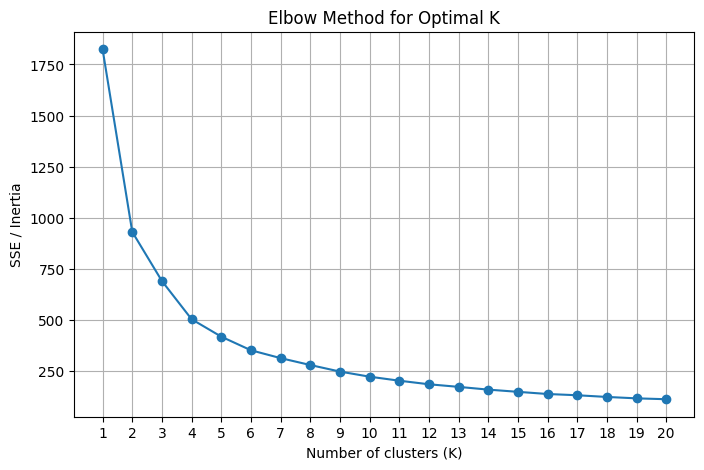

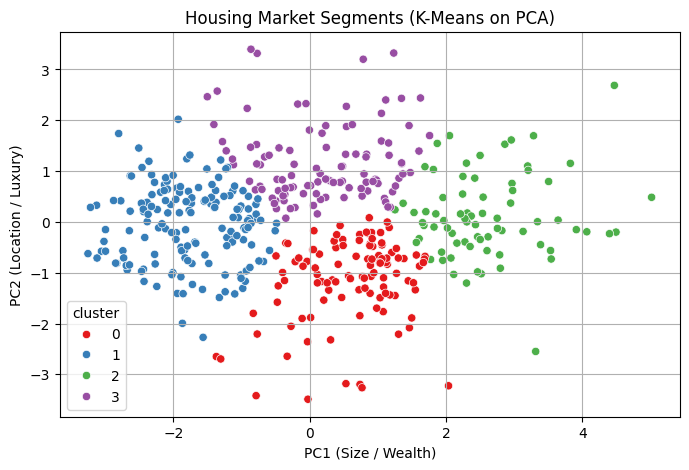

In [ ]:
# =========================
# 1. LOAD DATA
# =========================
import pandas as pd

url = "https://raw.githubusercontent.com/nbishop1-umd/marketing-analytics-project/refs/heads/main/Housing.csv"
df = pd.read_csv(url)

# =========================
# 2. FEATURE SELECTION
# =========================
features = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'view',
    'waterfront'
]

df = df[features]

# =========================
# 3. DATA CLEANING
# =========================
# Convert to numeric (handles hidden issues)
df = df.apply(pd.to_numeric, errors='coerce')

# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Optional: Remove outliers (IQR method)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# =========================
# 4. STANDARDIZATION
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame (for readability)
X_scaled = pd.DataFrame(X_scaled, columns=features)

# =========================
# 5. PCA (DIMENSION REDUCTION)
# =========================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# =========================
# 6. ELBOW METHOD (CHOOSE K)
# =========================
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

K_range = range(1, 21)
sse = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=777, n_init=25)
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("SSE / Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(K_range)
plt.grid(True)
plt.show()

# =========================
# 7. FINAL K-MEANS MODEL
# =========================
kmeans = KMeans(n_clusters=4, random_state=777, n_init=25)
pca_df['cluster'] = kmeans.fit_predict(X_pca)

# =========================
# 8. FINAL VISUALIZATION (CLUSTERS)
# =========================
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set1'
)

plt.xlabel("PC1 (Size / Wealth)")
plt.ylabel("PC2 (Location / Luxury)")
plt.title("Housing Market Segments (K-Means on PCA)")
plt.grid(True)
plt.show()

**ENTER INTERPRETATIONS HERE**

## Conclusion

[Provide a brief summary of your findings and explain how these findings can be used to improve managerial decision making. In addition, discuss if there are any limitations to your analysis and avenues that can be explored for further research.

This section should only contain text, no code.
]

## Team cooperation

[Describe how your team approached this assignment, how the work was distributed, and (if any) the difficulties encountered during the assignment and how you resolved these.

This section should only contain text, no code.
]

Distribution of Labor and Task Delegation

* Abraha, Heven
* Aljarrah, Yazan
* Bishop, Nia
* Hernandez, Grant
* Jarosinski, Austin
* See, Julia